Recently I've been fascinated by the problem of model interpretability. Model interpretability deals with understanding and explaining how a given neural network works.  
I have been trying to understand the basics of interpretability using a toy CNN model trained on MNIST, the hello world of neural networks at this point.  

Although the field has moved on to language models, there are a few reasons I chose to first work with convolutional neural networks because this was my first work with interpretability.  
The primary reason for this is the instant feedback you can get by looking inside a CNN model, the activations of a CNN model are known to have distinct visual features. This makes it easy to get started and build some basic concepts before going a bit abstract.  

I have tried to go through this without a lot of literature reading, trying to build an intuition since this is the first time I've done this. This makes most of the work here derivative, but it also is a good guide on the understanding the intuition behind different steps.  
It's also a lot of fun :)


# Model Setup

It's simply a neural network with 2 convolutional layers and 1 linear layer.  
It was trained using fastai for some epochs.  

In [2]:
from torch import nn

class SimpleMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(16 * 7 * 7, 10),
        )

    def forward(self, x):
        return self.layers(x)

# looking at the first layer

I'm consistently going to use a single training example (an image of `9`) for a large part of the next section.  
The first point is trying to understand how the model works for a single input.  

prediction: 9
model definition (useful to look at the layers): SimpleMNIST(
  (layers): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=784, out_features=10, bias=True)
  )
)


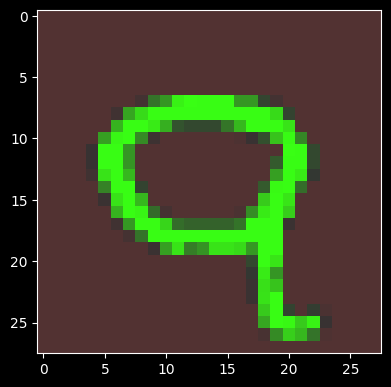

In [27]:
#| code-fold: true

from pt_to_api.utils import show_single_channel_red_green_black as S, to_show_list as tsl
import matplotlib.pyplot as plt
from pathlib import Path
import torch

MODEL_PATH = Path("../../pt-to-api/data/model.pt")
INPUT_PATH = Path("../../pt-to-api/data/first-input-tens.pt")

model = SimpleMNIST()
model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
inp_tens = torch.load(INPUT_PATH, "cpu", weights_only=False)

print("prediction:", torch.argmax(model(inp_tens)).item())
print("model definition (useful to look at the layers):", model)
S([inp_tens[0][0]], 4)
plt.show()

Lets look at the activations of the first layer.  

In [24]:
#| code-fold: true

class ModelSnapshot:
    def __init__(self, model):
        self.model = model
        self.activations = {}
        self.parameters = {}  # Dictionary to store weights and biases
        self.hooks = []
        
        # Capture static parameters once during init
        self._collect_parameters()
        # Register hooks for dynamic activations
        self._register_hooks()

    def _collect_parameters(self):
        """Extracts weights and biases for all layers that possess them."""
        for name, module in self.model.named_modules():
            layer_params = {}
            
            if hasattr(module, 'weight') and module.weight is not None:
                layer_params['weight'] = module.weight.detach().cpu()
            
            if hasattr(module, 'bias') and module.bias is not None:
                layer_params['bias'] = module.bias.detach().cpu()
            
            # Only add to the dictionary if the layer actually had parameters or config
            if layer_params:
                self.parameters[name] = layer_params

    def _register_hooks(self):
        for name, module in self.model.named_modules():
            hook = module.register_forward_hook(self._get_hook(name))
            self.hooks.append(hook)

    def _get_hook(self, name):
        def hook_fn(module, input, output):
            # Store the main activation output
            self.activations[name] = output.detach().cpu()
        return hook_fn

    def remove(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []


def get_model_internals(model, input_tensor):
    snapshot = ModelSnapshot(model)
    model.eval()

    if len(input_tensor.shape) == 3:
        input_tensor = input_tensor.unsqueeze(0)

    with torch.no_grad():
        _ = model(input_tensor)

    # Clean up hooks but keep the data
    activations = snapshot.activations
    activations["x"] = input_tensor
    parameters = snapshot.parameters
    snapshot.remove()
    
    return activations, parameters


We'll visualise the outputs of the first layer (`layers.0`) for our example.    
These are also called the activations of the first layer.   

Some notes on the visualisation strategy: 
- We see each channel's activation separately as a separate image.  
- The color scheme is important to understand
  - Green values are used for positive numbers, higher number = brighter green
  - Red is used for negative numbers, lower the number (or higher the absolute value) = brighter red
- It is useful to see activations whose absolute values are high
  - It is the first and the most primitive way we can think of a "signal" in the activations. Something different, an outlier.  
- In a single visualisation, all the numbers are scaled generally unless specified otherwise
  - In the grid below, you see very faded colors in the first image, that is because the numbers are consistently lesser than the numbers in the other images

We can clearly see the pattern of `9` in every output of the first layer.   

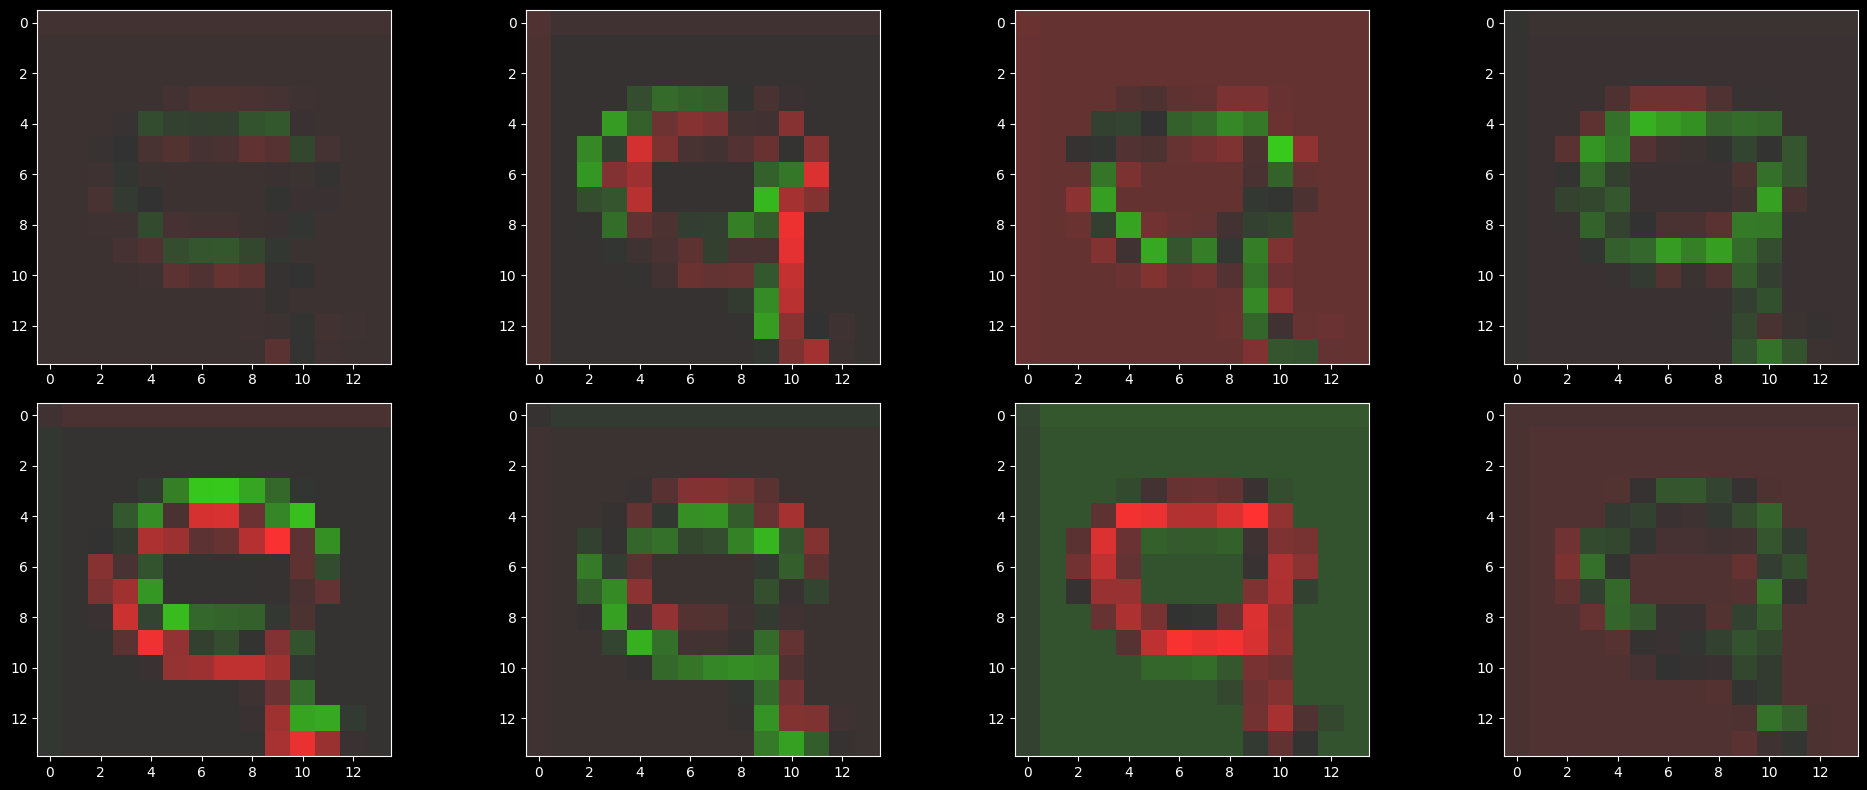

In [34]:
activations, parameters = get_model_internals(model, inp_tens)

activations.keys()

S(tsl(activations["layers.0"][0]), (20,8), ncols=4)
plt.show()

It is useful to see the convolution kernel, its input and its output for a given activation.  
The drill now is to analyse each activation individually, to see what the kernel is detecting.   

Let's take a look, at channel 1.  

In [43]:
activations["x"].shape

torch.Size([1, 1, 28, 28])

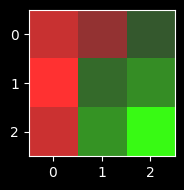

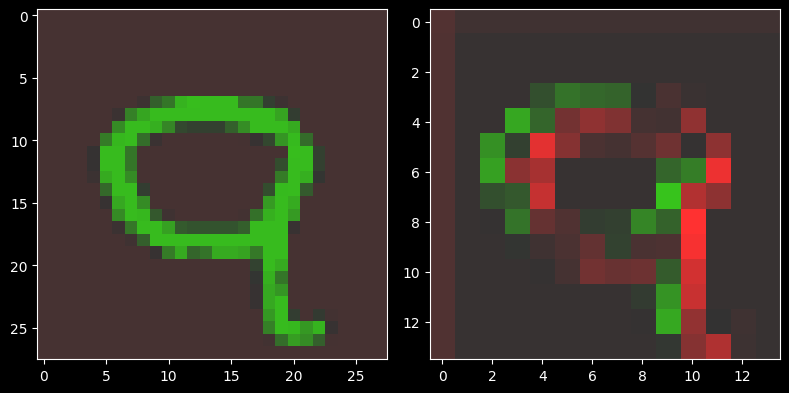

In [49]:
channel_1_weight = parameters["layers.0"]["weight"][1][0]

S([channel_1_weight], (2,2), ncols=1)
S([activations["x"][0][0], activations["layers.0"][0][1]], 8, ncols=2)
plt.show()

If you look at the output and the input side-by-side, it is evident that the kernel is extracting diagonals.  
There is a slightly more complicated story though.   

Convolutional networks don't learn clean kernels which would find a single pattern, like a vertical edge.  
They learn kernels which activate on a range of features and are more continuous.  

If you look at the output above, we can make the following statements about this kernel.  
- It detects diagonal lines, of the shape `/`
- It detects vertical lines too
- It either gives very low outputs or very negative outputs for diagonals of shape `\`, its a killer of that feature, this feature won't be visible in the next layer (ReLU zeros out negatives)
- The activation is the strongest for diagonals of shape `/`, and progressively becomes weaker as the pattern becomes vertical


While doing the analysis, it is quite useful to check out individual pixels, they tell surprising stories, we'll get to those later.  

Now, for any meaningful analysis, you need to check out all the convolutional kernels (and all channels, that is 136 individual 3x3 weights in this toy example).   
The final result can be thought of as forming a graph from the input pixels to the output pixels, with the dependency defined by each layer.  
As an example, the point `[4,4]` of the output in the above image is derived from the rectangular patch `[7:10, 7:10]`. In the dependency graph, that patch of pixels would be the parents of this output pixel.   

Analysing the whole dependency graph sounds very painful and labor intensive.   
An interesting thing about convolutional kernels is that they allow a very few input patterns to pass through, like in the above example, it allowed diagonal and vertical edges.   
Almost everything else is noise.  

We need to find a subgraph that we can analyse, that we judge to be the important part of the model's reasoning.  

# Find the important subgraph

How does a convolutional network decide that something is `9`? If we look at the output of the final layer, we see something like this:

In [ ]:
print(model(inp_tens).clone().detach().numpy()[0])

[ -3.537409  -30.710592   -7.707942  -11.665258  -17.290602  -12.1672535
 -13.942573   -1.9795344 -14.059631    9.588106 ]


If you look at the outputs, you'll see that the maximum number is the last one (the one for index `9`). The core point here is that the model looks for higher values.   

The question now is, why is that value high?  

## Finding the maximal activation path

The last linear layer of our model is 784 inputs and 10 outputs. For each output, the layer has 784 weights (or coefficients).   

The output calculation for the number coming at the last index is simply:
```python
Sum(w[i]*x[i])
```

Consider a set of numbers that we are adding: `1 + 9 + 4 = 14`   

The ratios contribution by each number to the final sum can simply be found by dividing each number by the final sum.  
The ratios are `0.07, 0.64, 0.28` respective. We can frame it as "the contribution of the first number to the final sum is `0.07`".   

This is the core thought, now we just need to define how we are going to spread the contribution for each layer successively in the network.   

One last thing though, what about negative numbers? Lets take a look at an example. `1 + -5 + 8 + -3 = 1`.  
We could divide by the final sum, and it does give us individual contributions correctly scaled (if you don't keep a constraint around keeping it between 0 and 1).   
What if our sum ends up being `0` though, division by 0 is invalid.  

Consider now sets of numbers and their sums: `1 + 1 = 2` and `-5 + 7 = 2`, if we find contributions by diving by the sum, then the numbers in the first two set get `0.5,0.5` respectively (which makes sense). The second set gets `-2.5, 3.5`. These numbers don't seem comparable at all.  

For this reason, I decided to divide by the sum of absolute numbers.  So the new contributions for `-5 + 7 = 2` would be `[-5/12, 7/12] = [-0.42, 0.58]` (where `12` is the absolute sum of the numbers).  

So the algorithm is basically this:
- From the final outputs, we spread the contributions to the last linear layer's input as `w[i]*x[i] / sum(abs(w[i]*x[i]))`
- For the convolutional layer, each pixel is derived from a cube of a convolutional 


> Although I was very confident in my reasoning, we'll also see later that this formulation has its own problems
> Formally this approach is a variation of an existing method called LRP
> There are many methods for finding the subgraph of importance inside a neural network, and many of them give different results
> It's an active area of research
> I'm going to settle on one method and move on for now

In [59]:
-5/12, 7/12

(-0.4166666666666667, 0.5833333333333334)